In [ ]:
from pathlib import Path
import json
import matplotlib as mpl
import matplotlib.pyplot as plt

EXPORT_ROOT = Path("paper_exports")
EXPORT_TABLES = EXPORT_ROOT / "tables"
EXPORT_FIGS = EXPORT_ROOT / "figures"
EXPORT_LOGS = EXPORT_ROOT / "logs"
for p in [EXPORT_ROOT, EXPORT_TABLES, EXPORT_FIGS, EXPORT_LOGS]:
    p.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 900,
    "savefig.transparent": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "font.size": 10
})

print("Figures:", EXPORT_FIGS.resolve())
print("Tables:", EXPORT_TABLES.resolve())
print("Logs:", EXPORT_LOGS.resolve())


cr = Path("current_run.txt")

run_rel = cr.read_text().strip()
RUN_PATH = Path("experiments") / Path(run_rel)

CONFIG_PATH = RUN_PATH / "config.json"
if not CONFIG_PATH.exists():
    raise RuntimeError(f"config.json not found at {CONFIG_PATH}. Make sure the run is prepared.")

CONFIG = json.load(open(CONFIG_PATH))
RESULTS_PATH = RUN_PATH / "results"


Figures: C:\Projects\multimodal_realestate_ml_public\paper_exports\figures
Tables: C:\Projects\multimodal_realestate_ml_public\paper_exports\tables
Logs: C:\Projects\multimodal_realestate_ml_public\paper_exports\logs


# ABLATION

#### common helper methods for ablation runs

In [2]:
import numpy as np
import pandas as pd
import time
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone

df_w = pd.read_csv("1-transaction-data/price_series.csv", index_col="date", parse_dates=True)
counts_df = pd.read_csv("1-transaction-data/counts_series.csv", index_col="date", parse_dates=True)
sent_df = pd.read_csv("2-sentiment-data/nsi_features_smooth.csv", index_col="date", parse_dates=True)
sar_df = pd.read_csv("3-satellite-data/weekly_sar_aligned.csv", index_col="date", parse_dates=True)
ir_series = pd.read_csv("4-interest-rate-data/interest_rate_series.csv", index_col="date", parse_dates=True).squeeze("columns")

sar_df = sar_df.reindex(df_w.index).ffill()
sent_df = sent_df.reindex(df_w.index).ffill()
ir_series = ir_series.reindex(df_w.index).ffill()

selected_master_projects = [
    "Business Bay", "DAMAC HILLS 2", "DAMAC HILLS", "TOWN SQUARE", "DownTown Dubai",
    "Dubai Creek Harbour", "Dubai Marina", "Dubai South Residential District",
    "Dubai Sports City", "Al Furjan", "International City Phase 1", "Jumeirah Lakes Towers",
    "Jumeirah Village Circle", "Jumeirah Village Triangle", "Jumeriah Beach Residence  - JBR",
    "Mudon", "Palm Jumeirah", "Silicon Oasis", "The Greens"
]

region_targets = selected_master_projects + ["Global"]

sent_cols = [
    c for c in sent_df.columns
    if c == "nsi_value" or c.startswith("nsi_") or (c.startswith("sem_pca") and c.endswith("_smooth"))
]

region_sat_cols = {r: [c for c in sar_df.columns if c.startswith(f"{r}__")] for r in region_targets}

window = 12
horizons = [2, 6, 10, 14, 18, 22, 26, 30, 34]

modalities_order = ["P", "C", "S", "B", "I", "G"]
order_index = {m: i for i, m in enumerate(modalities_order)}

def canonicalize_tag(tag):
    letters = sorted(list(set(tag)), key=lambda x: order_index[x])
    return "".join(letters)

def build_flat_ir(tag, h, tgt):
    X = []
    y = []
    d = []
    sat_cols = region_sat_cols.get(tgt, [])
    for i in range(window, len(df_w) - h):
        d.append(df_w.index[i])
        parts = []
        if "P" in tag:
            parts.append(df_w[tgt].iloc[i - window:i].values)
        if "C" in tag:
            parts.append(counts_df[tgt].iloc[i - window:i].values)
        if "S" in tag:
            parts.append(sent_df.iloc[i][sent_cols].values)
        if "B" in tag and sat_cols:
            parts.append(sar_df.iloc[i][sat_cols].values)
        if "I" in tag:
            parts.append(ir_series.iloc[i - window:i].values)
        if "G" in tag:
            parts.append(df_w["Global"].iloc[i - window:i].values)
            parts.append(counts_df["Global"].iloc[i - window:i].values)
        if not parts:
            continue
        X.append(np.hstack(parts))
        y.append(df_w[tgt].iloc[i + h])
    if len(X) == 0:
        return np.zeros((0, 0)), np.zeros((0,)), pd.DatetimeIndex([])
    return np.vstack(X), np.array(y), pd.DatetimeIndex(d)

def make_rolling_folds(idx, n_folds=10, train_years=5, val_months=6,
                       start=pd.Timestamp("2015-09-01"), end=pd.Timestamp("2025-10-01")):
    folds = []
    cur = start
    for _ in range(n_folds):
        train_end = cur + pd.DateOffset(years=train_years)
        val_end = train_end + pd.DateOffset(months=val_months)
        if val_end > end:
            break
        tr = (idx >= cur) & (idx < train_end)
        va = (idx >= train_end) & (idx < val_end)
        if tr.sum() > 0 and va.sum() > 0:
            folds.append((tr, va, cur, train_end, val_end))
        cur = cur + pd.DateOffset(months=val_months)
    return folds

knn_pipe = Pipeline([
    ("sc", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7, weights="uniform", leaf_size=30, p=1, n_jobs=-1))
])

def eval_knn_tag_mae(tag_label, tick_every=50):
    tag = canonicalize_tag(tag_label)
    maes_all = []
    total_local = len(region_targets) * len(horizons)
    done_local = 0
    t0 = time.perf_counter()
    print(f"[Start] {tag_label} (canonical={tag})")
    for reg in region_targets:
        for h in horizons:
            Xf, yf, idx = build_flat_ir(tag, h, reg)
            if Xf.shape[0] == 0 or Xf.shape[1] == 0:
                done_local += 1
                continue
            folds = make_rolling_folds(idx)
            for tr, va, _, _, _ in folds:
                mdl = clone(knn_pipe).fit(Xf[tr], yf[tr])
                pred = mdl.predict(Xf[va])
                maes_all.append(mean_absolute_error(yf[va], pred))
            done_local += 1
            if tick_every is not None and tick_every > 0:
                if done_local % tick_every == 0 or done_local == total_local:
                    pct = 100.0 * done_local / total_local
                    print(f"  [{tag_label}] {done_local}/{total_local} ({pct:.1f}%)")
    elapsed = time.perf_counter() - t0
    print(f"[Done ] {tag_label} in {elapsed:.1f}s")
    if len(maes_all) == 0:
        return np.nan
    return float(np.mean(maes_all))


### endeg vs. exegenc additions

In [ ]:
modalities_order = ["P", "C", "S", "B", "I", "G"]
order_index = {m: i for i, m in enumerate(modalities_order)}

def canonicalize_tag(tag):
    letters = sorted(list(set(tag)), key=lambda x: order_index[x])
    return "".join(letters)

transactional_basenames = ["P", "PC", "PCG"]

exogenous_extensions = [
    "",
    "S",
    "B",
    "I",
    "SB",
    "SI",
    "BI",
    "SBI"
]

records = []

for baseline in transactional_basenames:
    seen_tags = set()
    for ext in exogenous_extensions:
        full = canonicalize_tag(baseline + ext)
        if full in seen_tags:
            continue
        seen_tags.add(full)
        mae_val = eval_knn_tag_mae(full)
        records.append({
            "baseline": baseline,
            "tag": full,
            "mae_mean": mae_val
        })

df_enrichment = pd.DataFrame(records).dropna(subset=["mae_mean"])

chain_order_map = {}

for baseline in transactional_basenames:
    order = []
    seen = set()
    for ext in exogenous_extensions:
        full = canonicalize_tag(baseline + ext)
        if full not in df_enrichment[df_enrichment["baseline"] == baseline]["tag"].values:
            continue
        if full in seen:
            continue
        seen.add(full)
        order.append(full)
    chain_order_map[baseline] = order

baseline_chains = {}
summary_rows = []

for baseline in transactional_basenames:
    sub = df_enrichment[df_enrichment["baseline"] == baseline].copy()
    if sub.empty:
        baseline_chains[baseline] = None
        continue
    order = chain_order_map[baseline]
    sub = sub.set_index("tag").reindex(order).reset_index()
    base_row = sub[sub["tag"] == baseline]
    if len(base_row) != 1:
        sub["delta_vs_baseline"] = np.nan
        baseline_chains[baseline] = sub
        continue
    base_val = float(base_row["mae_mean"].iloc[0])
    sub["delta_vs_baseline"] = sub["mae_mean"] - base_val
    baseline_chains[baseline] = sub

    best_row = sub.sort_values("mae_mean", ascending=True).iloc[0]
    best_tag = best_row["tag"]
    best_mae = float(best_row["mae_mean"])
    delta_best = best_mae - base_val
    pct_best = (delta_best / base_val) * 100.0 if base_val != 0 else np.nan
    summary_rows.append({
        "baseline": baseline,
        "baseline_mae": base_val,
        "best_tag": best_tag,
        "best_mae": best_mae,
        "delta_best_vs_baseline": delta_best,
        "pct_best_vs_baseline": pct_best
    })

df_enrichment_summary = pd.DataFrame(summary_rows)

for baseline in transactional_basenames:
    print(f"\nTransactional baseline: {baseline}")
    chain = baseline_chains.get(baseline)
    if chain is None or chain.empty:
        print("(no data for this baseline)")
    else:
        display(chain)

print("\nSummary of best exogenous enrichments per transactional baseline:")
display(df_enrichment_summary)


[Start] P (canonical=P)
  [P] 50/180 (27.8%)
  [P] 100/180 (55.6%)
  [P] 150/180 (83.3%)
  [P] 180/180 (100.0%)
[Done ] P in 54.0s
[Start] PS (canonical=PS)
  [PS] 50/180 (27.8%)
  [PS] 100/180 (55.6%)
  [PS] 150/180 (83.3%)
  [PS] 180/180 (100.0%)
[Done ] PS in 52.4s
[Start] PB (canonical=PB)
  [PB] 50/180 (27.8%)
  [PB] 100/180 (55.6%)
  [PB] 150/180 (83.3%)
  [PB] 180/180 (100.0%)
[Done ] PB in 53.8s
[Start] PI (canonical=PI)
  [PI] 50/180 (27.8%)
  [PI] 100/180 (55.6%)
  [PI] 150/180 (83.3%)
  [PI] 180/180 (100.0%)
[Done ] PI in 20.9s
[Start] PSB (canonical=PSB)
  [PSB] 50/180 (27.8%)
  [PSB] 100/180 (55.6%)
  [PSB] 150/180 (83.3%)
  [PSB] 180/180 (100.0%)
[Done ] PSB in 90.9s
[Start] PSI (canonical=PSI)
  [PSI] 50/180 (27.8%)
  [PSI] 100/180 (55.6%)
  [PSI] 150/180 (83.3%)
  [PSI] 180/180 (100.0%)
[Done ] PSI in 59.7s
[Start] PBI (canonical=PBI)
  [PBI] 50/180 (27.8%)
  [PBI] 100/180 (55.6%)
  [PBI] 150/180 (83.3%)
  [PBI] 180/180 (100.0%)
[Done ] PBI in 63.7s
[Start] PSBI (canoni

,tag,baseline,mae_mean,delta_vs_baseline
0,P,P,3.876381,0.000000
1,PS,P,3.543781,-0.332600
2,PB,P,3.365881,-0.510500
3,PI,P,3.564353,-0.312027
4,PSB,P,3.201555,-0.674825
5,PSI,P,3.327215,-0.549166
6,PBI,P,3.241893,-0.634488
7,PSBI,P,3.101717,-0.774664



Transactional baseline: PC


,tag,baseline,mae_mean,delta_vs_baseline
0,PC,PC,3.667304,0.000000
1,PCS,PC,3.415622,-0.251681
2,PCB,PC,3.271436,-0.395867
3,PCI,PC,3.293955,-0.373349
4,PCSB,PC,3.162588,-0.504716
5,PCSI,PC,3.178884,-0.488420
6,PCBI,PC,3.130718,-0.536586
7,PCSBI,PC,3.061244,-0.606060



Transactional baseline: PCG


,tag,baseline,mae_mean,delta_vs_baseline
0,PCG,PCG,3.169089,0.000000
1,PCSG,PCG,3.122236,-0.046852
2,PCBG,PCG,3.053858,-0.115231
3,PCIG,PCG,2.996785,-0.172303
4,PCSBG,PCG,3.035127,-0.133961
5,PCSIG,PCG,2.988875,-0.180214
6,PCBIG,PCG,2.954344,-0.214744
7,PCSBIG,PCG,2.957027,-0.212061



Summary of best exogenous enrichments per transactional baseline:


,baseline,baseline_mae,best_tag,best_mae,delta_best_vs_baseline,pct_best_vs_baseline
0,P,3.876381,PSBI,3.101717,-0.774664,-19.984198
1,PC,3.667304,PCSBI,3.061244,-0.606060,-16.526028
2,PCG,3.169089,PCBIG,2.954344,-0.214744,-6.776221


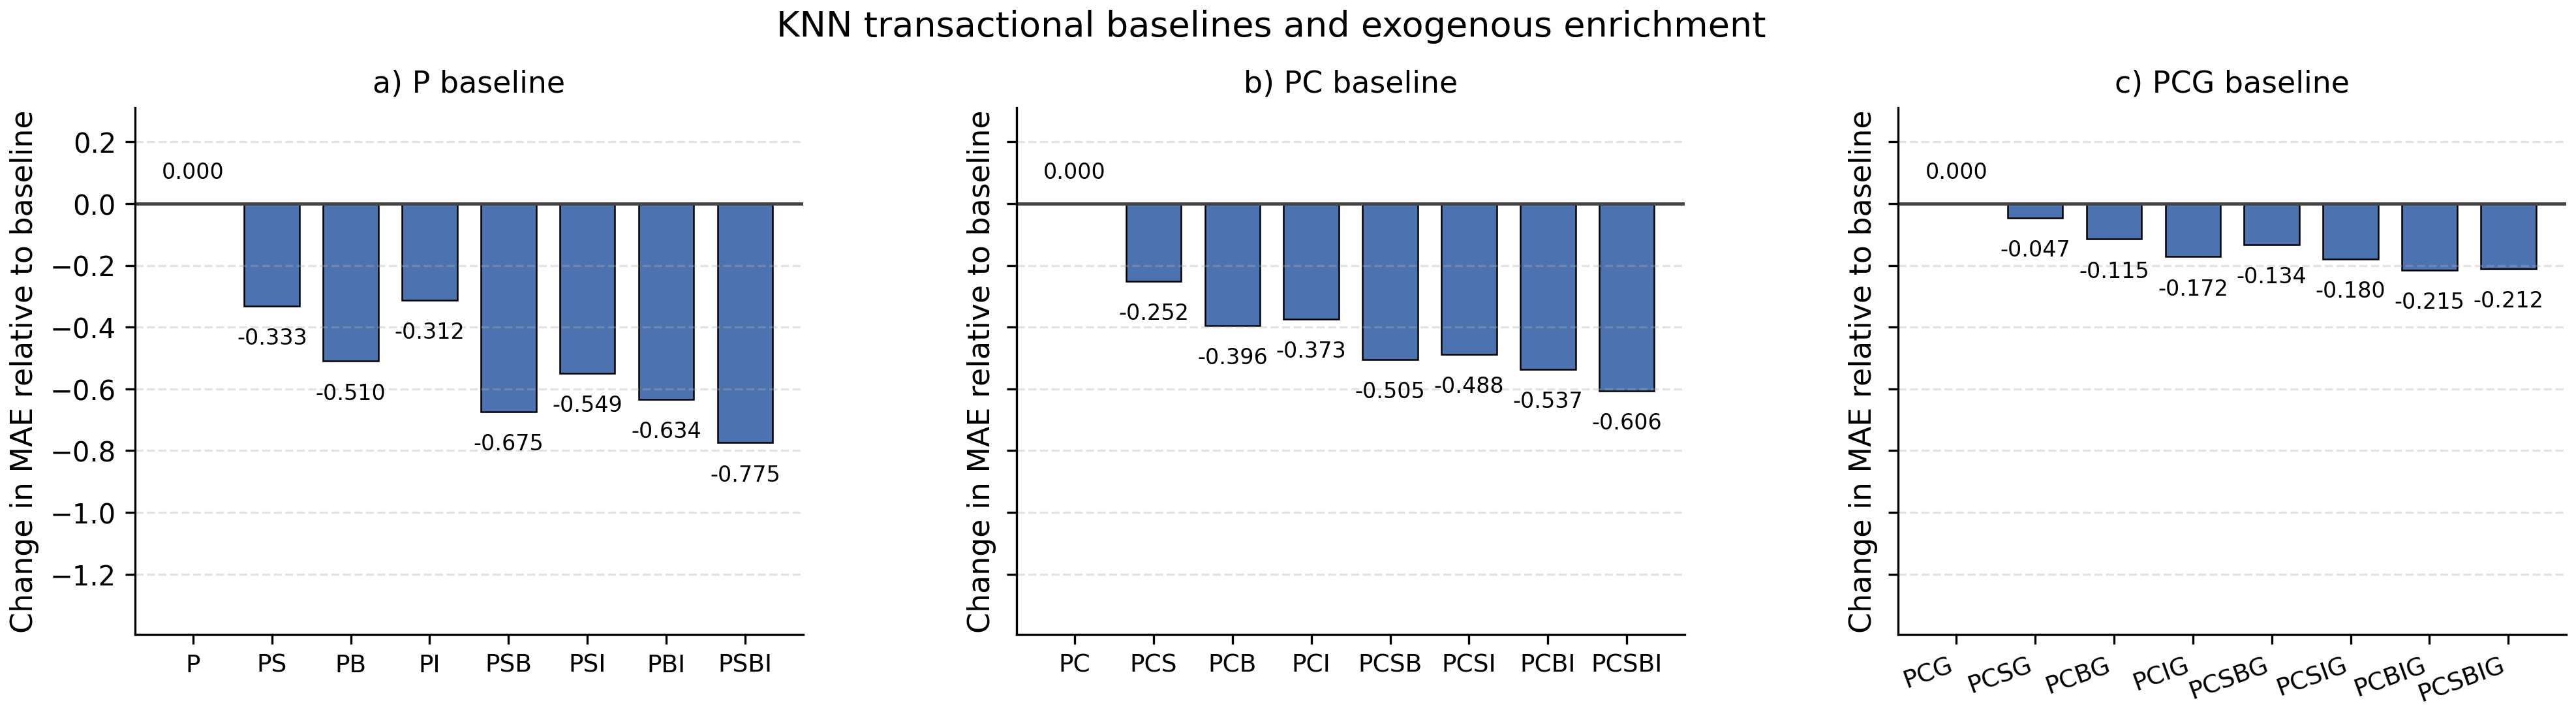

Saved transactional baseline enrichment figure to: C:\Projects\multimodal_realestate_ml_public\paper_exports\figures\knn_transactional_baselines_enrichment.png


In [ ]:
baseline_order = ["P", "PC", "PCG"]

all_deltas = []
for baseline in baseline_order:
    chain = baseline_chains.get(baseline)
    vals = chain["delta_vs_baseline"].values
    all_deltas.extend(vals.tolist())

if len(all_deltas) > 0:
    vmin = np.nanmin(all_deltas)
    vmax = np.nanmax(all_deltas)
    limit = max(abs(vmin), abs(vmax))
    y_min = -1.8 * limit
    y_max = 0.4 * limit
else:
    y_min = None
    y_max = None

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
axes = np.atleast_1d(axes)

bar_color = "#4C72B0"

title_map = {
    "P": "a) P baseline",
    "PC": "b) PC baseline",
    "PCG": "c) PCG baseline"
}

for ax, baseline in zip(axes, baseline_order):
    chain = baseline_chains.get(baseline)
    if chain is None or chain.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=11)
        ax.axis("off")
        continue

    xs = np.arange(len(chain))
    vals = chain["delta_vs_baseline"].values
    bars = ax.bar(xs, vals, width=0.7, color=bar_color, edgecolor="black", linewidth=0.6)

    ax.axhline(0.0, color="#444444", linewidth=1.2)

    ax.set_xticks(xs)
    ax.set_xticklabels(chain["tag"].tolist(), rotation=0, fontsize=9)
    ax.set_ylabel("Change in MAE relative to baseline", fontsize=11)

    panel_title = title_map.get(baseline, baseline)
    ax.set_title(panel_title, fontsize=11)

    if y_min is not None and y_max is not None:
        ax.set_ylim(y_min, y_max)
        span = y_max - y_min
    else:
        span = 1.0

    ax.grid(axis="y", linestyle="--", alpha=0.35)

    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            x_pos = bar.get_x() + bar.get_width() / 2
            if v >= 0:
                y_pos = v + 0.04 * span
                va = "bottom"
            else:
                y_pos = v - 0.04 * span
                va = "top"
            ax.text(x_pos, y_pos, f"{v:.3f}", ha="center", va=va, fontsize=8)

    if baseline == "PCG":
        for label in ax.get_xticklabels():
            label.set_rotation(20)
            label.set_ha("right")

plt.subplots_adjust(top=0.86, bottom=0.22, left=0.07, right=0.99, wspace=0.32)
fig.suptitle("KNN transactional baselines and exogenous enrichment", fontsize=13, y=0.98)

outfile = EXPORT_FIGS / "knn_transactional_baselines_enrichment.png"
fig.savefig(outfile, bbox_inches="tight")
plt.show()
fig.savefig(outfile, dpi=900, format="png", bbox_inches="tight", pad_inches=0.05)
plt.close(fig)

print("Saved transactional baseline enrichment figure to:", outfile.resolve())


## Exegen only

In [ ]:
suite_D_tags = ["C", "S", "B", "CS", "CB", "SB", "CSB", "G"]
baselines = ["P", "PCSBIG"]
eval_tags = suite_D_tags + baselines

def eval_knn_tag_mae(tag_label, tick_every=25):
    tag = canonicalize_tag(tag_label)
    maes_all = []
    total_local = len(region_targets) * len(horizons)
    done_local = 0
    t0 = time.perf_counter()
    print(f"[Start] {tag_label} (canonical={tag})")
    for reg in region_targets:
        for h in horizons:
            Xf, yf, idx = build_flat_ir(tag, h, reg)
            if Xf.shape[0] == 0:
                continue
            folds = make_rolling_folds(idx)
            for tr, va, _, _, _ in folds:
                mdl = clone(knn_pipe).fit(Xf[tr], yf[tr])
                pred = mdl.predict(Xf[va])
                maes_all.append(mean_absolute_error(yf[va], pred))
            done_local += 1
            if done_local % tick_every == 0:
                pct = 100.0 * done_local / total_local
                print(f"  [{tag_label}] {done_local}/{total_local} ({pct:.1f}%)")
    elapsed = time.perf_counter() - t0
    print(f"[Done ] {tag_label} in {elapsed:.1f}s")
    if len(maes_all) == 0:
        return np.nan
    return float(np.mean(maes_all))

rows = []
for t in eval_tags:
    rows.append({"tag": t, "model": "KNN", "mae_mean": eval_knn_tag_mae(t)})

df_mae = pd.DataFrame(rows).dropna(subset=["mae_mean"])

if not set(baselines).issubset(set(df_mae["tag"])):
    missing = [b for b in baselines if b not in set(df_mae["tag"])]
    raise RuntimeError(f"Missing baseline MAE for: {missing}")

base_P = float(df_mae.loc[df_mae["tag"] == "P", "mae_mean"].iloc[0])
base_ALL = float(df_mae.loc[df_mae["tag"] == "PCSBIG", "mae_mean"].iloc[0])

df_exog = df_mae[df_mae["tag"].isin(suite_D_tags)].copy()
df_exog["delta_vs_P"] = df_exog["mae_mean"] - base_P
df_exog["delta_vs_ALL"] = df_exog["mae_mean"] - base_ALL

dfa = df_exog.sort_values("delta_vs_P", ascending=True).reset_index(drop=True)
dfb = df_exog.sort_values("delta_vs_ALL", ascending=True).reset_index(drop=True)

print("\nExogenous only KNN with G included – MAE and delta columns:")
display(df_exog.sort_values("mae_mean")[["tag", "mae_mean", "delta_vs_P", "delta_vs_ALL"]])


[Start] C (canonical=C)
  [C] 25/180 (13.9%)
  [C] 50/180 (27.8%)
  [C] 75/180 (41.7%)
  [C] 100/180 (55.6%)
  [C] 125/180 (69.4%)
  [C] 150/180 (83.3%)
  [C] 175/180 (97.2%)
[Done ] C in 54.1s
[Start] S (canonical=S)
  [S] 25/180 (13.9%)
  [S] 50/180 (27.8%)
  [S] 75/180 (41.7%)
  [S] 100/180 (55.6%)
  [S] 125/180 (69.4%)
  [S] 150/180 (83.3%)
  [S] 175/180 (97.2%)
[Done ] S in 86.3s
[Start] B (canonical=B)
  [B] 25/180 (13.9%)
  [B] 50/180 (27.8%)
  [B] 75/180 (41.7%)
  [B] 100/180 (55.6%)
  [B] 125/180 (69.4%)
  [B] 150/180 (83.3%)
  [B] 175/180 (97.2%)
[Done ] B in 88.0s
[Start] CS (canonical=CS)
  [CS] 25/180 (13.9%)
  [CS] 50/180 (27.8%)
  [CS] 75/180 (41.7%)
  [CS] 100/180 (55.6%)
  [CS] 125/180 (69.4%)
  [CS] 150/180 (83.3%)
  [CS] 175/180 (97.2%)
[Done ] CS in 55.0s
[Start] CB (canonical=CB)
  [CB] 25/180 (13.9%)
  [CB] 50/180 (27.8%)
  [CB] 75/180 (41.7%)
  [CB] 100/180 (55.6%)
  [CB] 125/180 (69.4%)
  [CB] 150/180 (83.3%)
  [CB] 175/180 (97.2%)
[Done ] CB in 57.6s
[Start] SB

,tag,mae_mean,delta_vs_P,delta_vs_ALL
5,SB,3.498437,-0.377943,0.541410
6,CSB,3.541281,-0.335100,0.584254
4,CB,3.884381,0.008000,0.927354
2,B,3.895504,0.019123,0.938476
7,G,4.206473,0.330092,1.249446
3,CS,4.493976,0.617595,1.536949
1,S,4.981277,1.104896,2.024250
0,C,5.508170,1.631789,2.551143


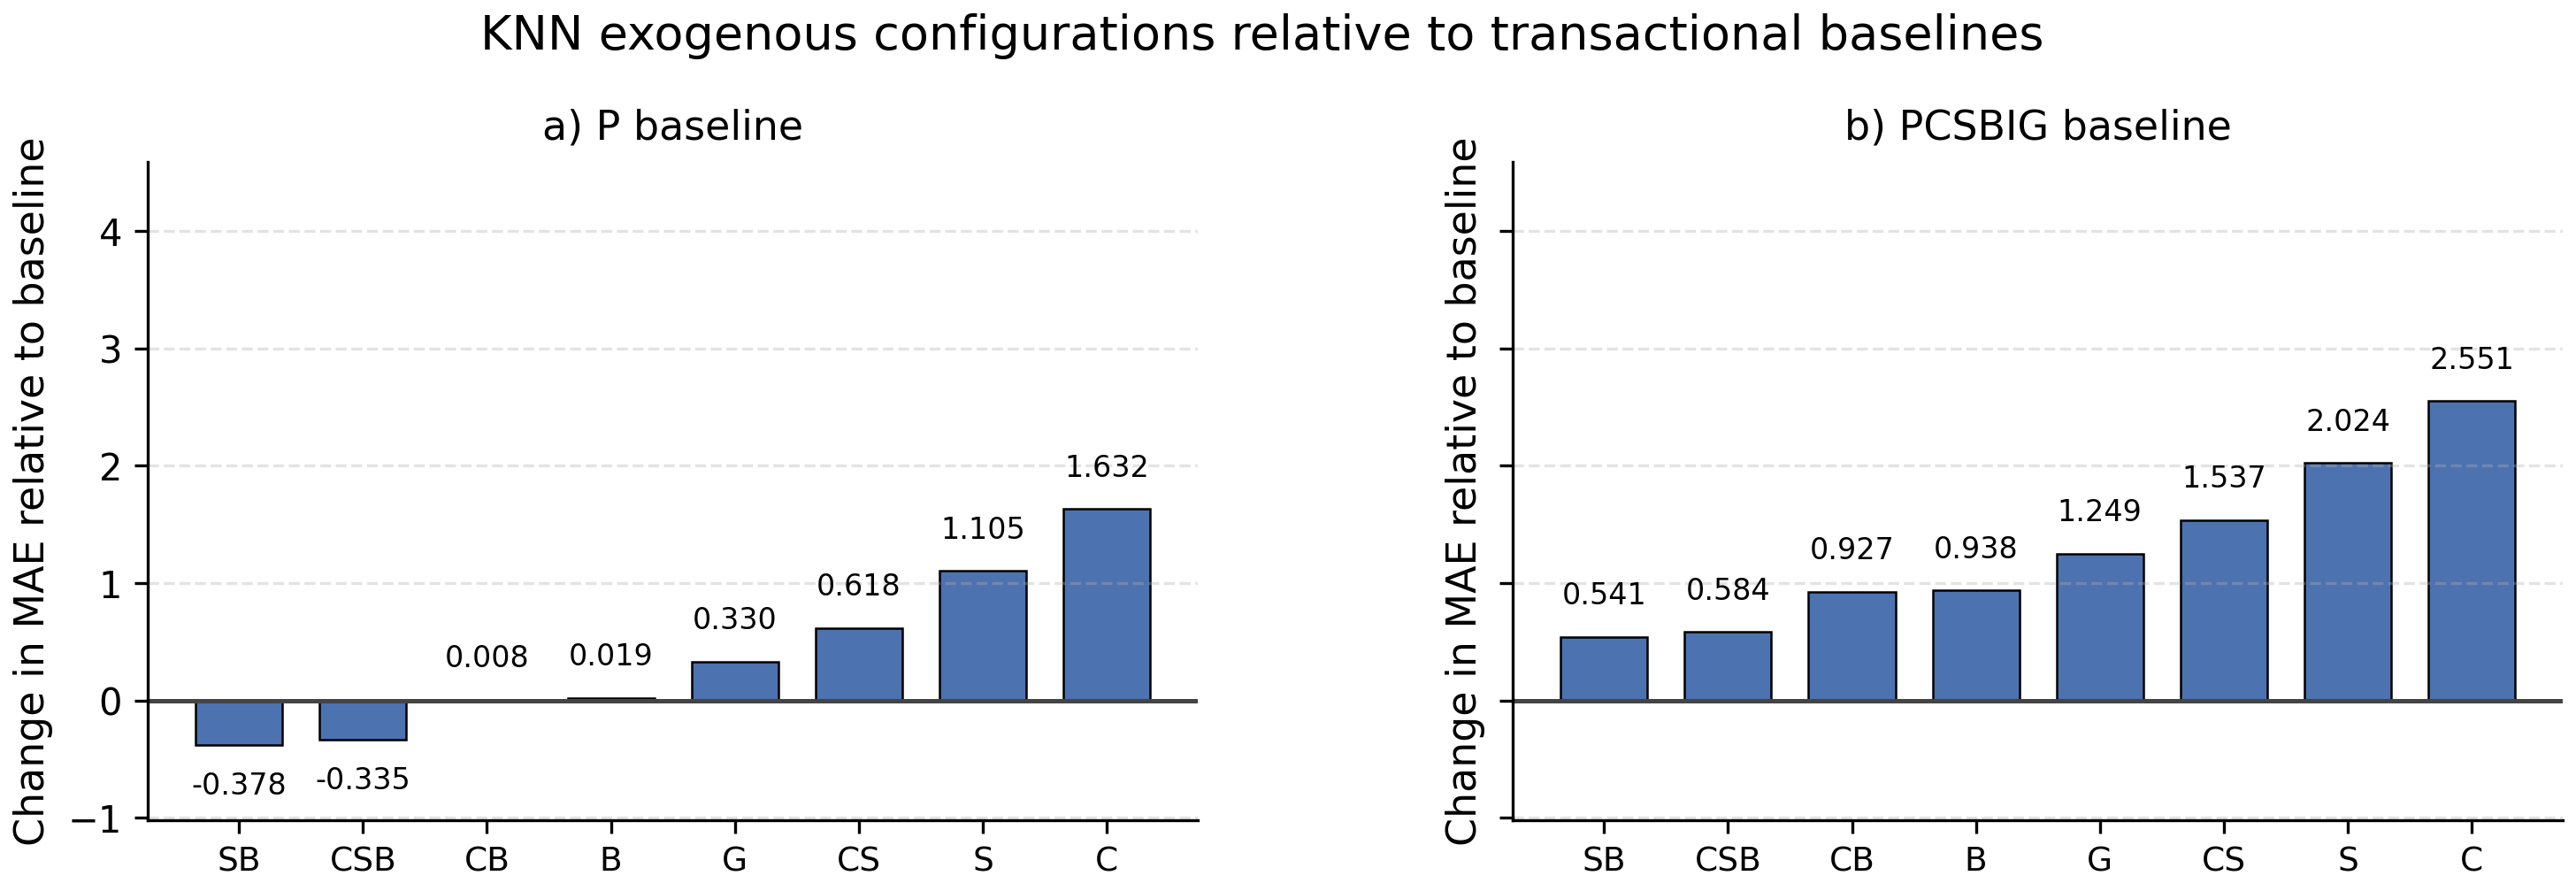

Saved exogenous only enrichment figure to: C:\Projects\multimodal_realestate_ml_public\paper_exports\figures\knn_exogenous_only_enrichment.png


In [ ]:
all_deltas = []
for col in ["delta_vs_P", "delta_vs_ALL"]:
    vals = df_exog[col].values
    all_deltas.extend(vals.tolist())

if len(all_deltas) > 0:
    vmin = np.nanmin(all_deltas)
    vmax = np.nanmax(all_deltas)
    limit = max(abs(vmin), abs(vmax))
    y_min = -0.4 * limit
    y_max = 1.8 * limit

else:
    y_min = None
    y_max = None

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0), sharey=True)
axes = np.atleast_1d(axes)

bar_color = "#4C72B0"

panel_info = [
    ("delta_vs_P", "a) P baseline"),
    ("delta_vs_ALL", "b) PCSBIG baseline")
]

data_views = [dfa, dfb]

for ax, (col, title), df_view in zip(axes, panel_info, data_views):
    if df_view is None or df_view.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=11)
        ax.axis("off")
        continue

    xs = np.arange(len(df_view))
    vals = df_view[col].values
    bars = ax.bar(xs, vals, width=0.7, color=bar_color, edgecolor="black", linewidth=0.6)

    ax.axhline(0.0, color="#444444", linewidth=1.2)

    ax.set_xticks(xs)
    ax.set_xticklabels(df_view["tag"].tolist(), rotation=0, fontsize=9)
    ax.set_ylabel("Change in MAE relative to baseline", fontsize=11)

    ax.set_title(title, fontsize=11)

    if y_min is not None and y_max is not None:
        ax.set_ylim(y_min, y_max)
        span = y_max - y_min
    else:
        span = 1.0

    ax.grid(axis="y", linestyle="--", alpha=0.35)

    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            x_pos = bar.get_x() + bar.get_width() / 2
            if v >= 0:
                y_pos = v + 0.04 * span
                va = "bottom"
            else:
                y_pos = v - 0.04 * span
                va = "top"
            ax.text(x_pos, y_pos, f"{v:.3f}", ha="center", va=va, fontsize=8)

plt.subplots_adjust(top=0.84, bottom=0.22, left=0.08, right=0.99, wspace=0.30)
fig.suptitle("KNN exogenous configurations relative to transactional baselines", fontsize=13, y=0.98)

outfile = EXPORT_FIGS / "knn_exogenous_only_enrichment.png"
fig.savefig(outfile, bbox_inches="tight")
plt.show()
fig.savefig(outfile, dpi=900, format="png", bbox_inches="tight", pad_inches=0.05)
plt.close(fig)

print("Saved exogenous only enrichment figure to:", outfile.resolve())
